In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from functools import partial

### Problem 1c
Check the eigenvalues of both the delayed v. undelayed system

In [2]:
A = np.array([[0.5, 0], [0, 1]])
B = np.array([[0], [1]])
K = np.array([-1, -1.25])

BK = np.outer(B, K)

# undelayed dynamics: A+BK
undelayed = A + BK
delayed = np.block([[A, BK], [np.eye(2), np.zeros((2, 2))]])

rho_undelayed = max(np.abs(np.linalg.eigvals(undelayed)))
rho_delayed = max(np.abs(np.linalg.eigvals(delayed)))

print("Max complex modulus of eigenvalues of undelayed & delayed system, problem 1: ")
print(f"{rho_undelayed=}")
print(f"{rho_delayed=}")

Max complex modulus of eigenvalues of undelayed & delayed system, problem 1: 
rho_undelayed=0.5
rho_delayed=1.118033988749895


### Problem 5
Analyzing 2D nonlinear system equilibrium w/ dynamics:
$$
\dot x = f(x) = \begin{bmatrix} x_2 - 2 \\ -x_1 - x_2 + \frac 1 3 (x_1+1)^3 + 1 \end{bmatrix}
$$

In [21]:
# Defn f(x) in code:
def f(x):
    return np.array([[x[1] - 2], [-x[0] - x[1] + (1/3)*(x[0]+1)**3 + 1]])

In [4]:
# computed jacobian by hand and got:
def Jf(x):
    return np.array([[0, 1], [-1 + (x[0]+1)**2, -1]])

# Computed equilibrium pts by hand:
eqs = [[-1, 2], [-1 - np.sqrt(3), 2], [-1 + np.sqrt(3), 2]]

# Evaluating linearized equilibrium pts and their eigenvals:
print("Jacobian of f(x) evaluated at equilibrium points and its eigenvalues: ")
Jfe1 = Jf(eqs[0])
print(f"For x* = {[-1, 2]}, we have jacobian:\n {Jfe1}\n this has eigenvalues: {np.linalg.eigvals(Jfe1)}")

Jfe2 = Jf(eqs[1])
print(f"For x* = {eqs[1]}, we have jacobian:\n {Jfe2}\n this has eigenvalues: {np.linalg.eigvals(Jfe2)}")


Jfe3 = Jf(eqs[2])
print(f"For x* = {eqs[2]}, we have jacobian:\n {Jfe3}\n this has eigenvalues: {np.linalg.eigvals(Jfe3)}")

Jacobian of f(x) evaluated at equilibrium points and its eigenvalues: 
For x* = [-1, 2], we have jacobian:
 [[ 0  1]
 [-1 -1]]
 this has eigenvalues: [-0.5+0.8660254j -0.5-0.8660254j]
For x* = [-2.732050807568877, 2], we have jacobian:
 [[ 0.  1.]
 [ 2. -1.]]
 this has eigenvalues: [ 1. -2.]
For x* = [0.7320508075688772, 2], we have jacobian:
 [[ 0.  1.]
 [ 2. -1.]]
 this has eigenvalues: [ 1. -2.]


In [19]:
# Now to generate phase portrait, need N discretized pts about stable equilibrium pt
# Then at each of these grid pts evaluate f(x) to get direction system is moving given that initial state
# plot using plt.quiver

N = 20
x_pts, y_pts = np.linspace(eqs[0][0] - 4, eqs[0][0] + 4, num=N), np.linspace(eqs[0][1] - 4, eqs[0][1] + 4, num=N)
X, Y = np.meshgrid(x_pts, y_pts)

# Get points in shape (N, N, 2) -> x[i, j] gives a specific pt we can pass to f(x)
x = np.array([X, Y]).transpose(1, 2, 0)
x.shape

xdot = np.empty_like(x)
for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        xdot[i, j] = f(x[i, j]).reshape(-1)

U, V = xdot[..., 0], xdot[..., 1]

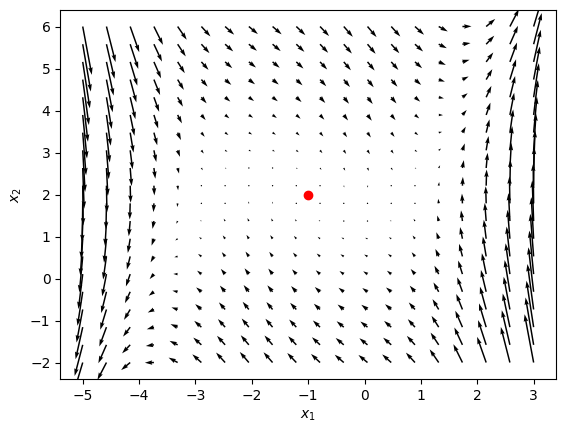

In [20]:
plt.quiver(X, Y, U, V)
plt.plot(*eqs[0], 'ro')  # mark equilibrium
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.show()

In [23]:
# To approximate region of attraction:
# Sample points in grid, integrate forward in time for some finite horizon T
# If trajectory[-1] close enough to eq. pt we say it converges
# Collect pts which converged and feed to scipy convex hull

# make f(x) -> f(t, x) to work w/ solve ivp
def f_ivp(t, x):
    return f(x).reshape(-1)

# Defn time horizon, and tolerance for error
x_star = eqs[0]
T = 50
tol = 1e-2

converged = []
for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        # Pick init value from grid and integrate forward in time
        x0 = x[i, j]
        soln = scipy.integrate.solve_ivp(f_ivp, [0, T], x0)
        xfinal = soln.y[:, -1]
        # check if close to eq. 
        if np.linalg.norm(xfinal - x_star) < tol:
            converged.append(x0)

converged = np.array(converged)
hull = scipy.spatial.ConvexHull(converged)
        

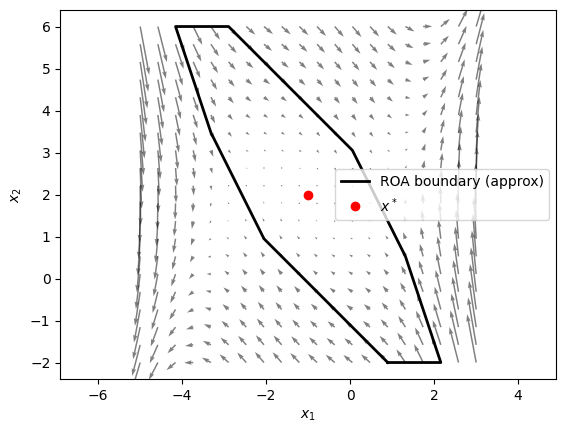

In [26]:
plt.quiver(X, Y, U, V, alpha=0.5)

hull_pts = converged[hull.vertices]
hull_pts = np.vstack([hull_pts, hull_pts[0]])  # close the loop
plt.plot(hull_pts[:, 0], hull_pts[:, 1], 'k-', linewidth=2, label='ROA boundary (approx)')

plt.plot(*x_star, 'ro', label='$x^*$')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.legend()
plt.axis('equal')
plt.show()

In [28]:
# Eyeball one init condition that converges one that doesn't
x0c = np.array([-2., 4.])
x0d = np.array([-4., 0.])

# solve ivp for both w/ dense output for plotting
soln1 =  scipy.integrate.solve_ivp(f_ivp, [0, T], x0c, dense_output=True)
soln2 = scipy.integrate.solve_ivp(f_ivp, [0, T], x0d, dense_output=True)

tvals = np.linspace(0, T, 100)
traj1 = soln1.sol(tvals)
traj2 = soln2.sol(tvals)

traj1.shape

(2, 100)

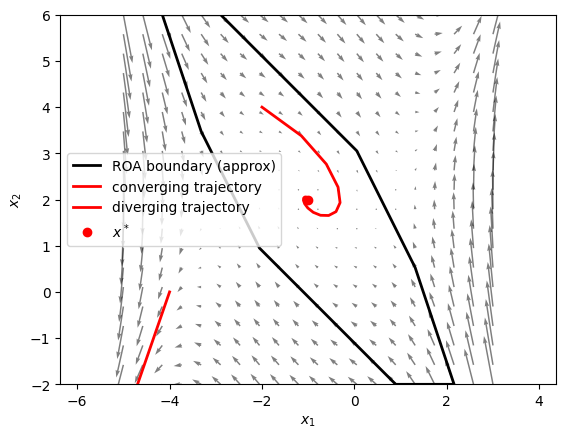

In [30]:
# Plot phase portrait, then hull, then trajectories:
plt.quiver(X, Y, U, V, alpha=0.5)
plt.plot(hull_pts[:, 0], hull_pts[:, 1], 'k-', linewidth=2, label='ROA boundary (approx)')
plt.plot(traj1[0], traj1[1], 'r-', linewidth=2, label='converging trajectory')
plt.plot(traj2[0], traj2[1], 'r-', linewidth=2, label='diverging trajectory')

plt.plot(*x_star, 'ro', label='$x^*$')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.legend()
plt.axis('equal')
plt.xlim(x_pts.min(), x_pts.max())
plt.ylim(y_pts.min(), y_pts.max())
plt.show()

### Problem 6
We have system: 
$$
\dot x = x^2 + a
$$
w/ a constant. We will draw phase plot w/ a=-1, determine equilibria (where xdot = 0) and draw bifurcation diagram

In [33]:
def xdot(x, a): return x**2 + a

# defn for a=-1
xdot_fixed = partial(xdot, a=-1)

# Sanity check: 1, -1 are equilibria for f(x) = x^2 - 1
xdot_fixed(1), xdot_fixed(-1)

(0, 0)

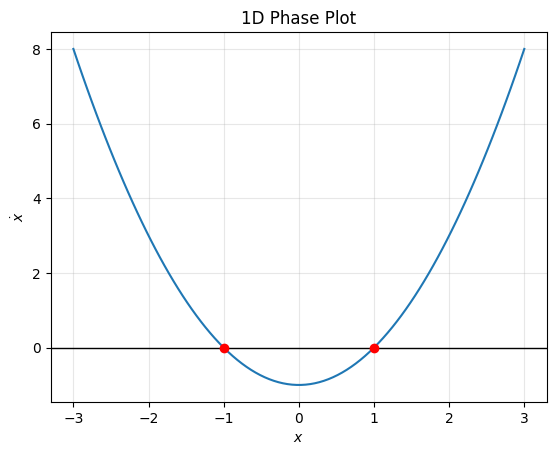

In [35]:
# Now to make 1d phase plot:

x = np.linspace(-3, 3, 100)
y = xdot_fixed(x)

eq_pts = [1, -1]
plt.axhline(0, color='black', linewidth=1)  # x-axis at y=0
plt.plot(x, y);
plt.plot(eq_pts, [0]*len(eq_pts), 'ro')

plt.xlabel('$x$')
plt.ylabel('$\\dot{x}$')
plt.title('1D Phase Plot')
plt.grid(alpha=0.3)
plt.show()

#### 6b) Bifurcation Diagram
For bifurcation diagram we are plotting equilibrium pts x* at y-axis and a along x-axis.

We take $\dot x = x^2 + a$, set to 0 and we see that $x* = \pm \sqrt{-a}$

##### Stability / Equilibrium
We can for which of the equilibria the system is stable by linearizing f(x):
$$df/dx = 2x$$
So for our stability points $x* = \pm \sqrt{-a}$:
- case 1: a > 0 then $x*$ is imaginary, no real equilibrium pt so nothing to say about stability
- case 2: a = 0 then $x* = 0$ and linearized dynamics are also 0 so we can't say whether stable/unstable
- case 3: a < 0 then we have 2 real equilibria at $\sqrt{-a}$ unstable and $-\sqrt{-a}$ locally exponentially stable

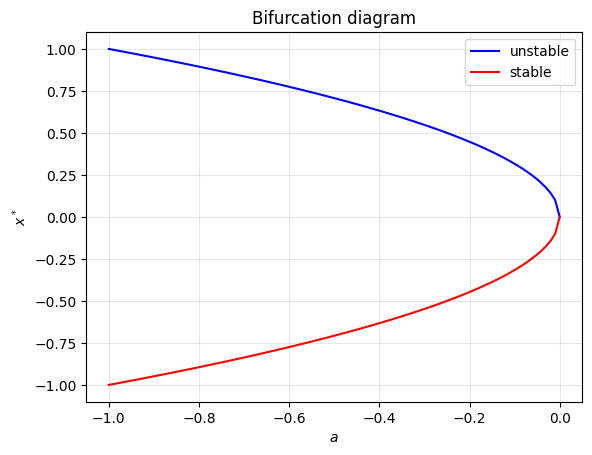

In [39]:
a = np.linspace(-1, 0, 100) # ignore a in 
x_star_plus = np.sqrt(-a) # unstable for a in [-1, 0)
x_star_minus = -np.sqrt(-a) # stable for a in [-1, 0)

plt.plot(a, x_star_plus, 'b-', label='unstable')
plt.plot(a, x_star_minus, 'r-', label = 'stable')
plt.xlabel('$a$')
plt.ylabel('$x^*$')
plt.title('Bifurcation diagram')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
M = np.array([[-1, 1], [0, 0]])
np.linalg.eigvals(M)

array([-1.,  0.])